### LIB

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder  , RobustScaler , StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , BatchNormalization
from tensorflow.keras.optimizers import Adam , AdamW
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau , ModelCheckpoint

In [221]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Feature Selection 

In [222]:
df["Deck"] = df["Cabin"].str.split("/").str[0]
df["Side"] = df["Cabin"].str.split("/").str[2]
df["Group"] = df["PassengerId"].str.split("_").str[0]
df["GroupSize"] = df.groupby("Group")["Group"].transform("count")
df.drop(columns=["PassengerId" , "Name" , "Cabin","Group"] , axis =1 , inplace= True)
df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side,GroupSize
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,P,1
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,S,1
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,S,2
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,S,2
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,A,P,1
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,G,S,1
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,G,S,1
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,E,S,2


### Missing Values 

In [223]:
df.isnull().sum()

HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
Deck            199
Side            199
GroupSize         0
dtype: int64

In [224]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Deck            2.289198
Side            2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
Transported     0.000000
GroupSize       0.000000
dtype: float64


Visualize the Missing Values 

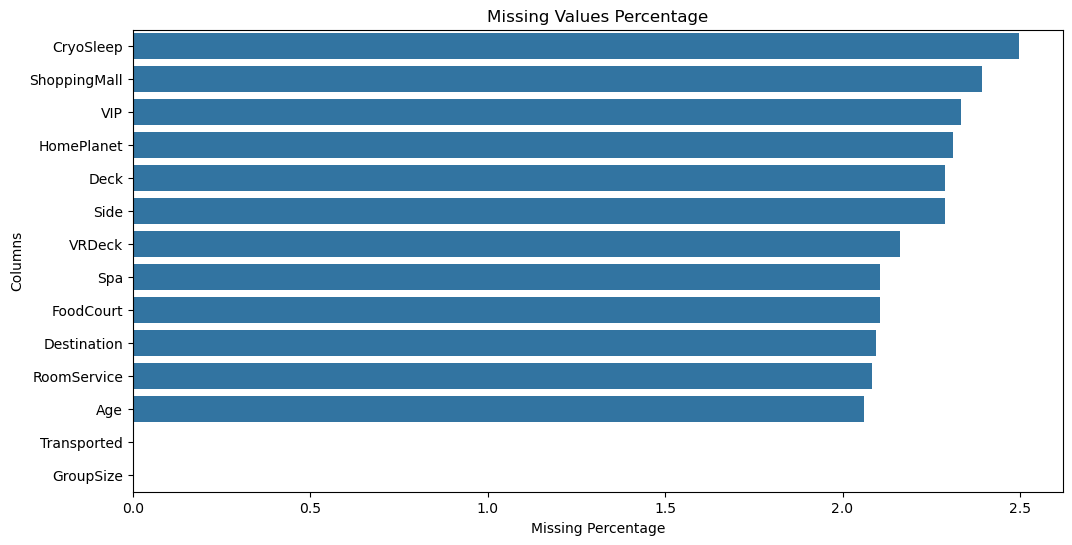

In [225]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.xlabel("Missing Percentage")
plt.ylabel("Columns")
plt.title("Missing Values Percentage")

plt.show()

### Handle Missing Values 

In [226]:
numerical_cols = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [227]:
categorical_cols = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP",
    "Deck",
    "Side"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\work\AppData\Local\Temp\ipykernel_6088\2284778750.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


### Feature Engineering 

In [228]:
#df["Total_Cost"] = df["RoomService"] + df["FoodCourt"] + df["ShoppingMall"] + df["Spa"] + df["VRDeck"]
#df.drop(columns=["RoomService" , "FoodCourt" , "ShoppingMall" , "Spa", "VRDeck"] , axis =1 , inplace= True)
#df

### Univariate Analysis

In [229]:
df[numerical_cols].describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.790291,220.009318,448.434027,169.572300,304.588865,298.261820
std,14.341404,660.519050,1595.790627,598.007164,1125.562559,1134.126417
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,41.000000,61.000000,22.000000,53.000000,40.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


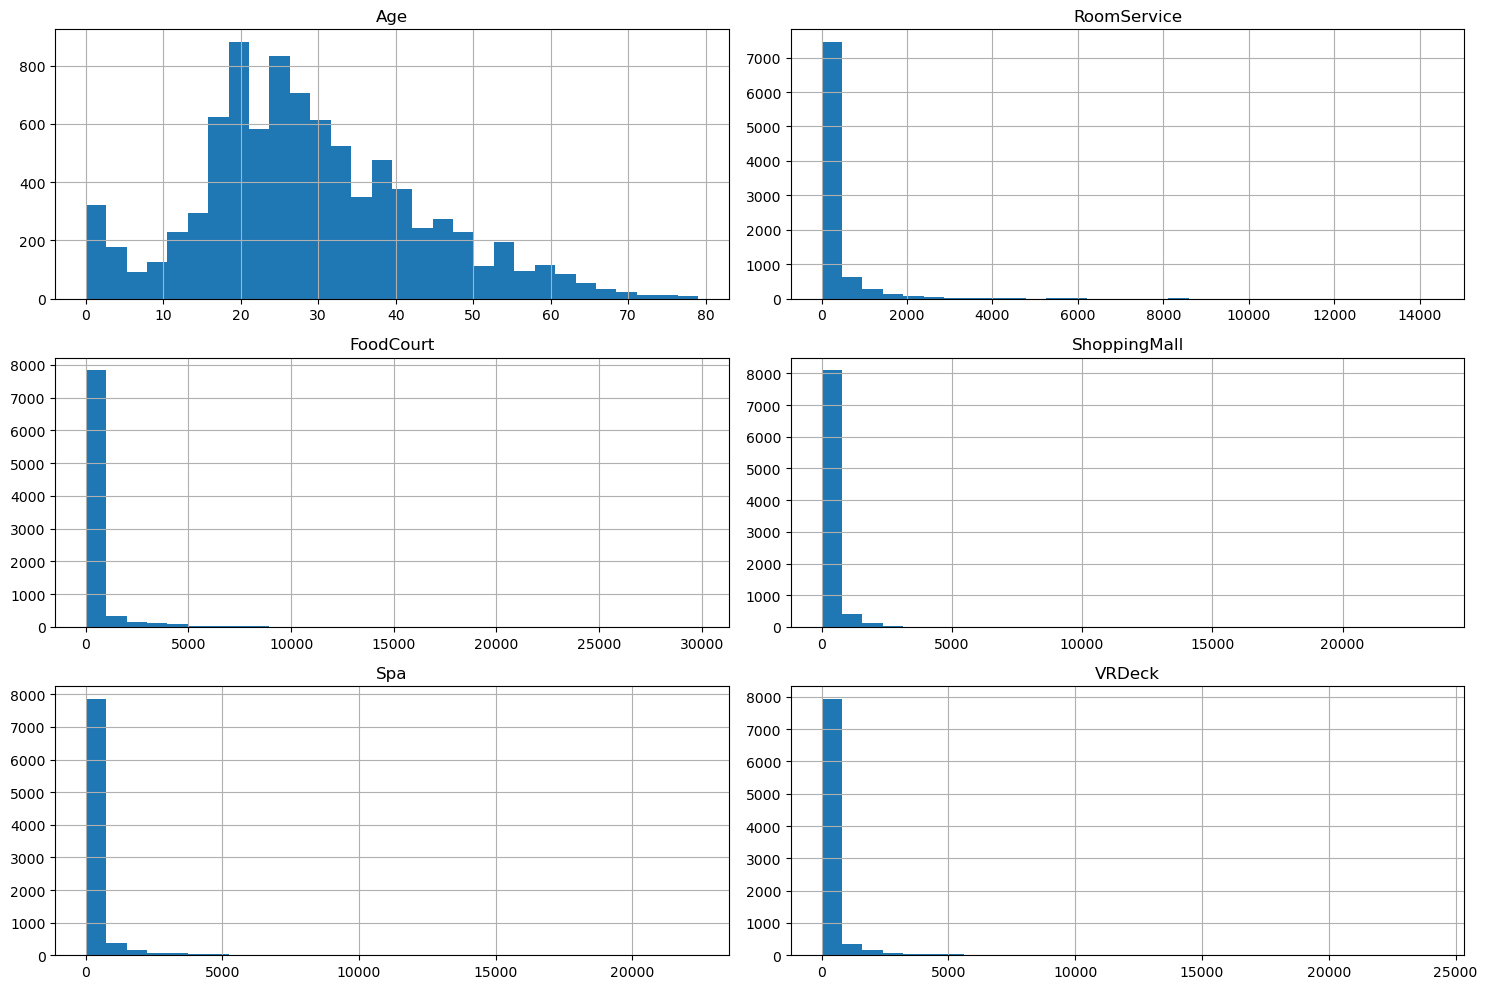

In [230]:
df[numerical_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

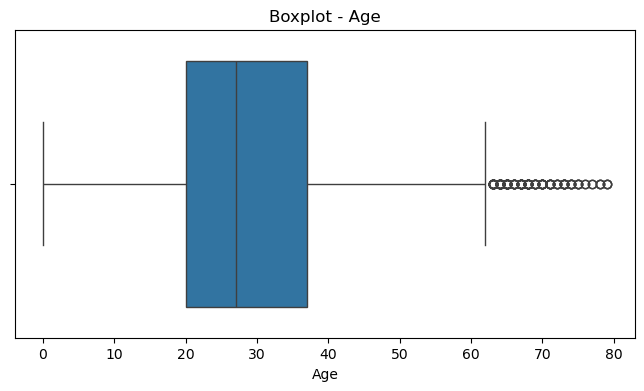

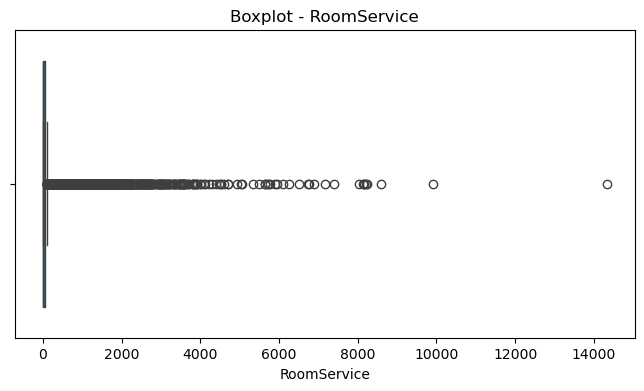

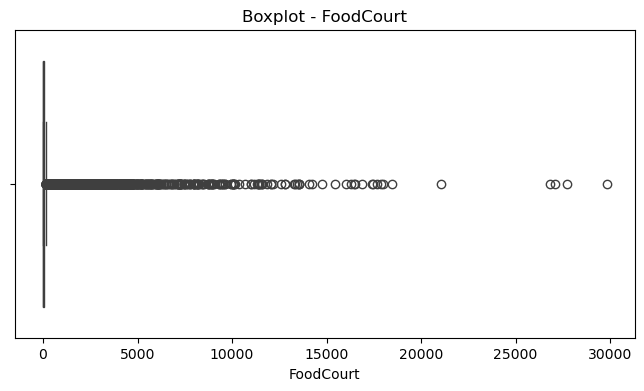

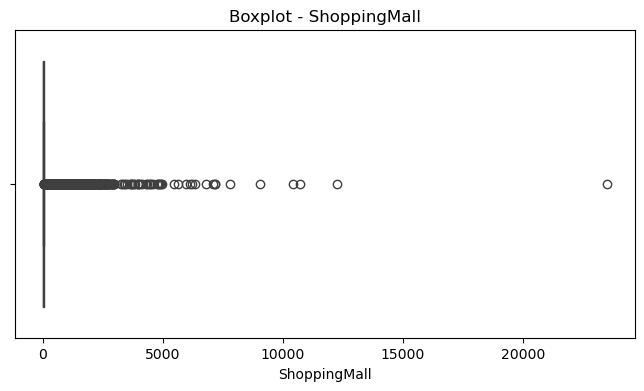

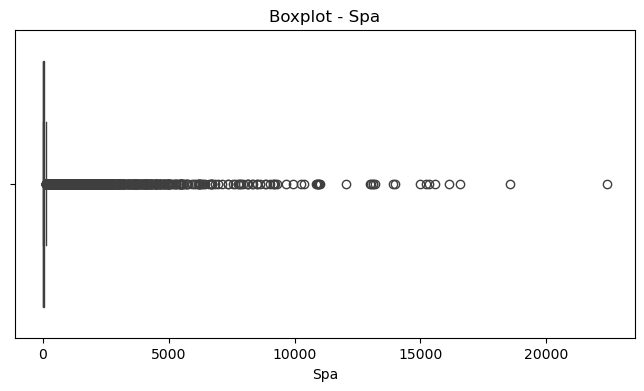

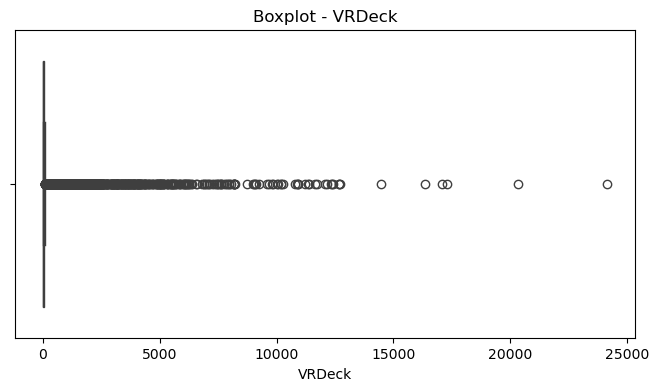

In [231]:
for col in numerical_cols:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f"Boxplot - {col}")
    
    plt.show()

### Handle Outliers

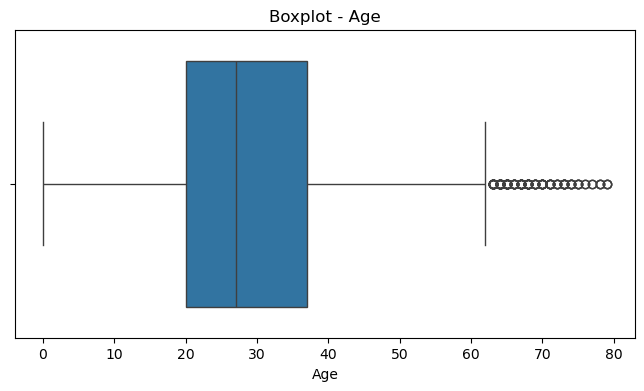

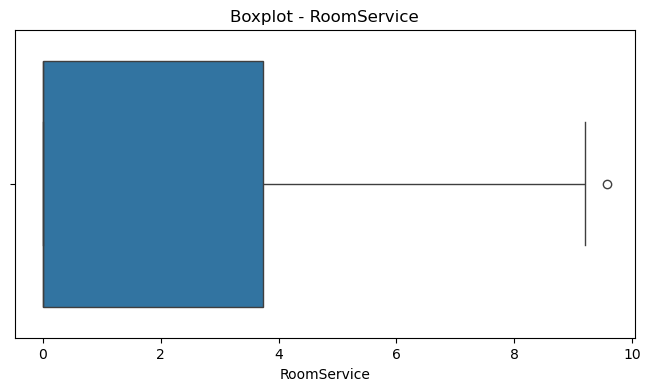

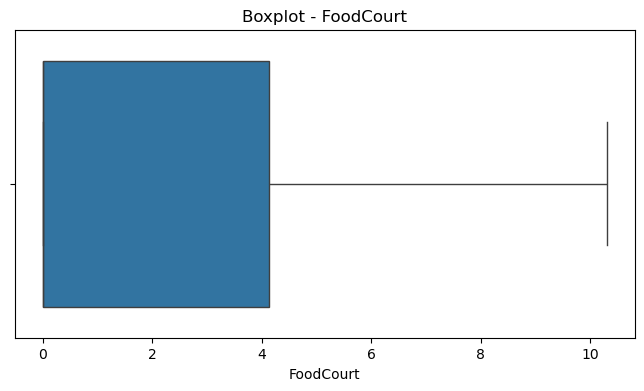

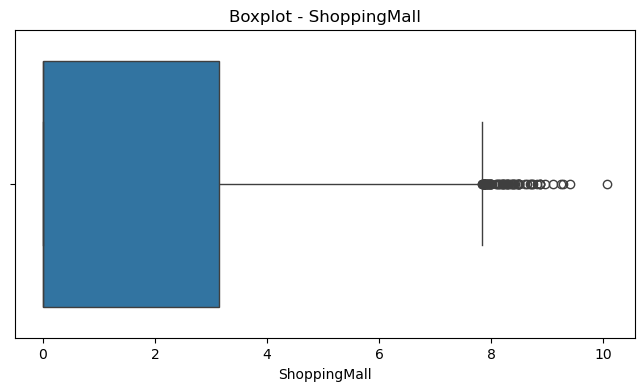

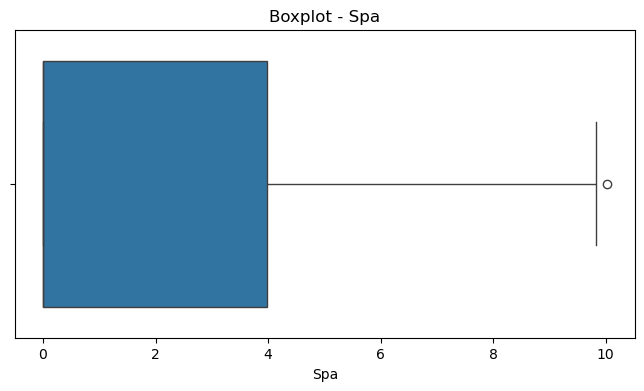

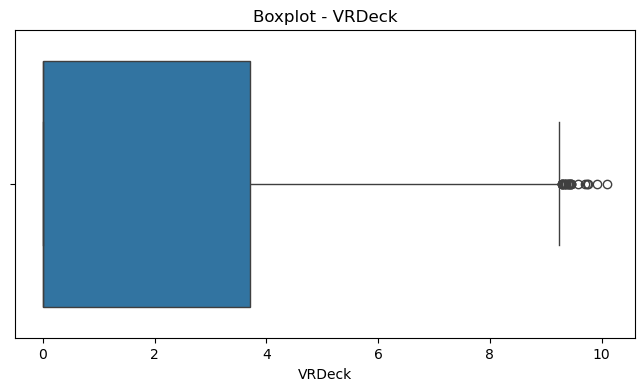

In [232]:
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

for col in spending_cols:
    df[col] = np.log1p(df[col])


for col in numerical_cols:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f"Boxplot - {col}")
    
    plt.show()





#If we Make Feature Engineering :

#df["Total_Cost"] = np.log1p(df["Total_Cost"])
#
#
#    
#plt.figure(figsize=(8, 4))
#
#sns.boxplot(
#    x=df["Total_Cost"]
#)
#
#plt.title(f"Boxplot - {col}")
#
#plt.show()

### Bivariate Analysis

Numerical Vs Target 

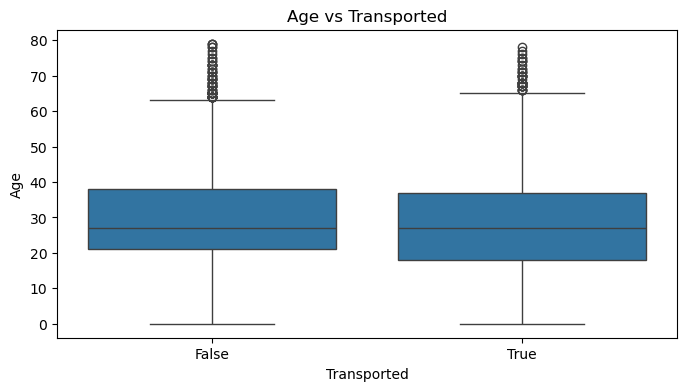

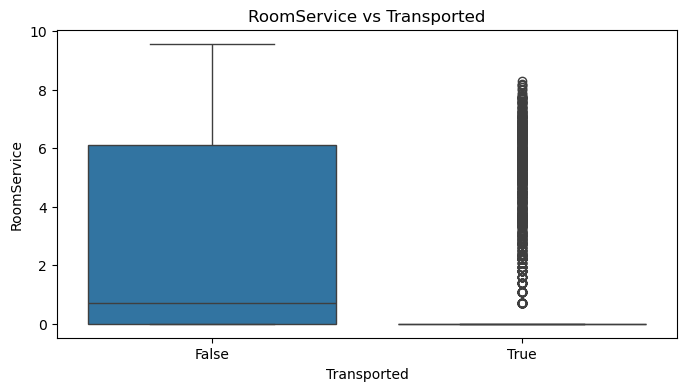

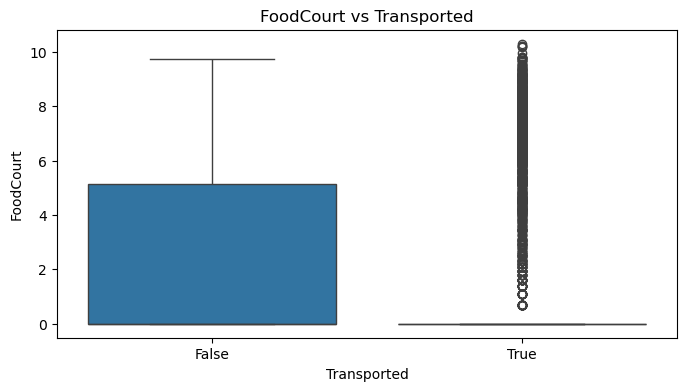

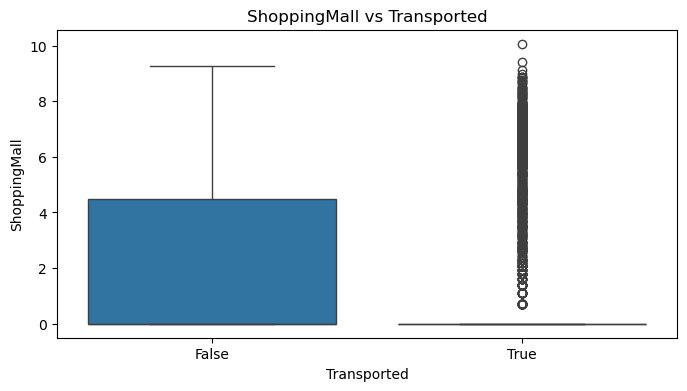

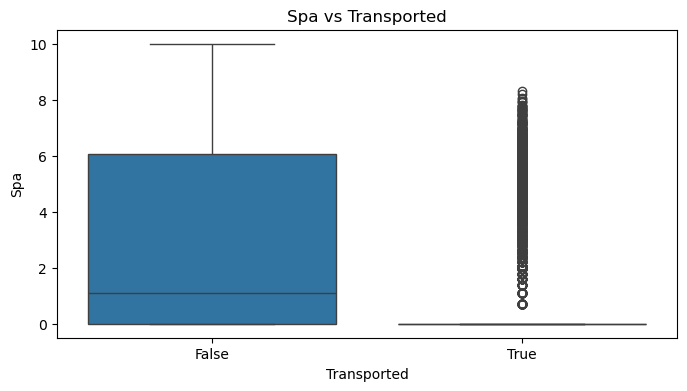

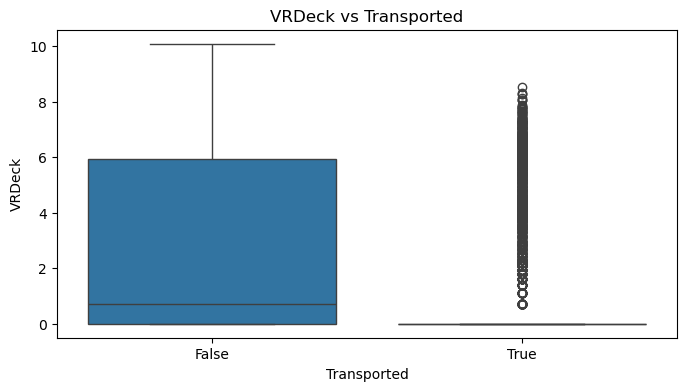

In [233]:
for col in numerical_cols:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x="Transported",
        y=col
    )
    
    plt.title(f"{col} vs Transported")
    
    plt.show()

Categorical Vs Target 

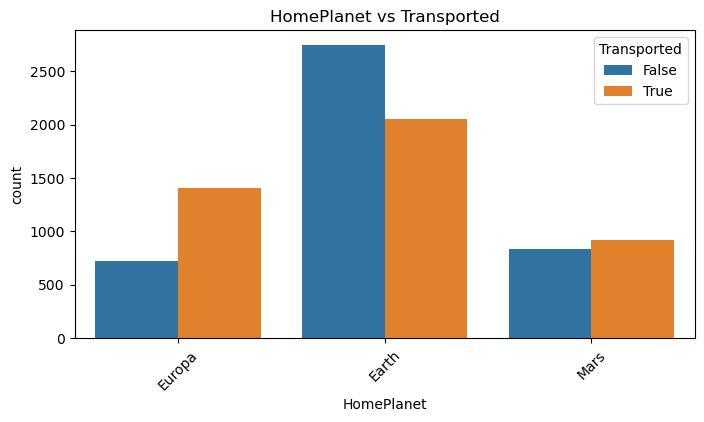

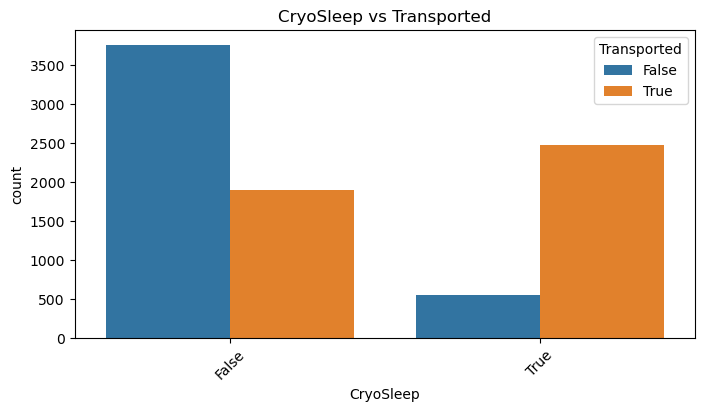

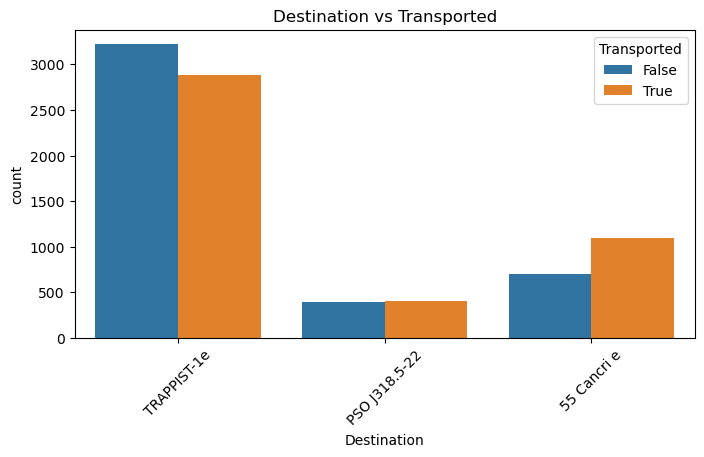

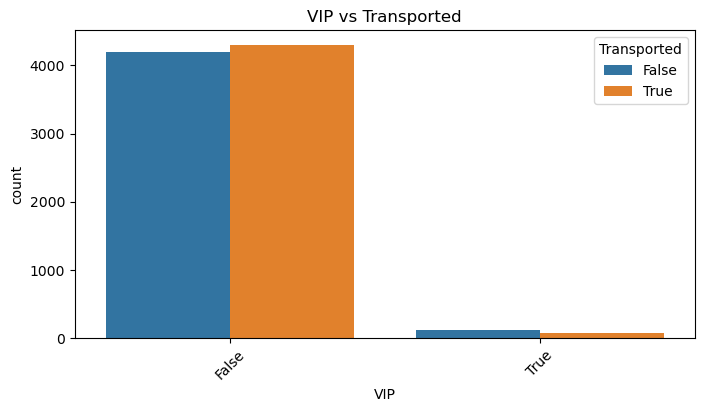

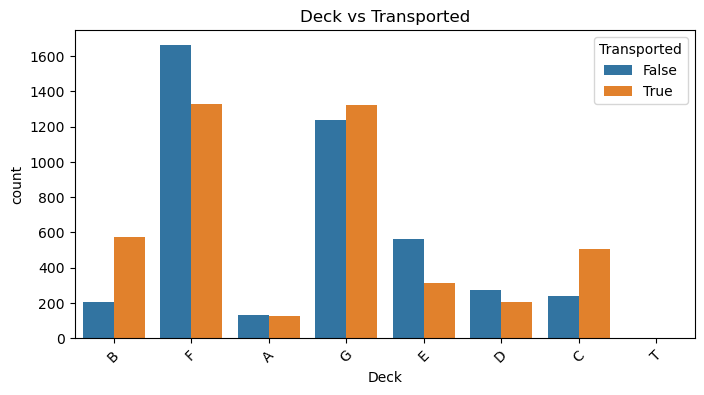

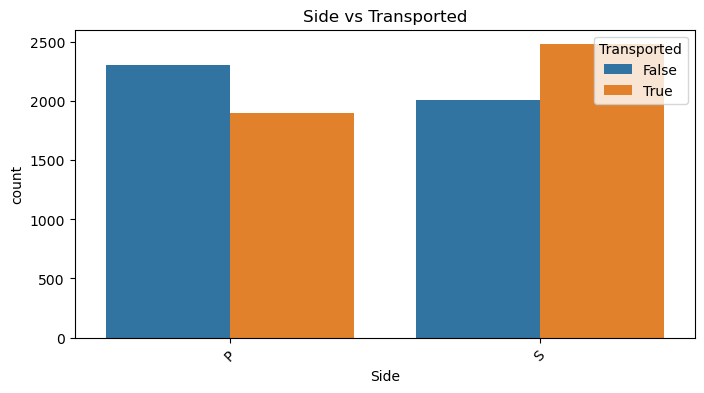

In [234]:
for col in categorical_cols:
    
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=df,
        x=col,
        hue="Transported"
    )
    
    plt.title(f"{col} vs Transported")
    
    plt.xticks(rotation=45)
    
    plt.show()

Correlation

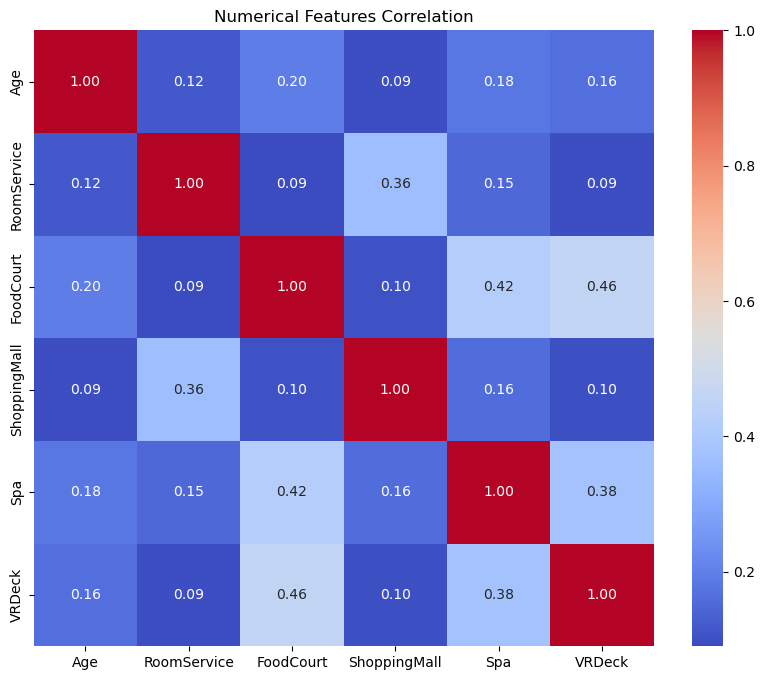

In [235]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Features Correlation")

plt.show()

### Target Anlaysis 

The Data Is Balance 

In [236]:
df["Transported"].value_counts(normalize=True)*100

Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64

### Feature Encoding 

In [237]:
# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        "HomePlanet",
        "Destination",
        "Deck",
        "Side"
    ],
    drop_first=False,
    dtype=int
)

# Boolean Encoding
df["CryoSleep"] = df["CryoSleep"].astype(int)
df["VIP"] = df["VIP"].astype(int)
df["Transported"] = df["Transported"].astype(int)

In [238]:
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
0,0,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,...,0,1,0,0,0,0,0,0,1,0
1,0,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,1,1,...,0,0,0,0,0,1,0,0,0,1
2,0,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,2,...,1,0,0,0,0,0,0,0,0,1
3,0,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,2,...,1,0,0,0,0,0,0,0,0,1
4,0,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,1,1,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.000000,8.827615,0.000000,7.404888,4.317488,0,1,...,1,0,0,0,0,0,0,0,1,0
8689,1,18.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,...,0,0,0,0,0,0,1,0,0,1
8690,0,26.0,0,0.000000,0.000000,7.535297,0.693147,0.000000,1,1,...,0,0,0,0,0,0,1,0,0,1
8691,0,32.0,0,0.000000,6.956545,0.000000,5.869297,8.082093,0,2,...,0,0,0,0,1,0,0,0,0,1


### Split the Data

In [239]:
X = df.drop(columns=["Transported"])
Y = df["Transported"]
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42,
    stratify=Y
)

### Feature Scalling 

In [240]:
numerical_cols = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
    "GroupSize"
]

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_val[numerical_cols] = scaler.transform(
    X_val[numerical_cols]
)

In [241]:
X_train

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,HomePlanet_Earth,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
3388,1,-0.116462,0,-0.641081,-0.650850,-0.621396,-0.661827,-0.640722,1.867520,0,...,0,0,0,1,0,0,0,0,1,0
1013,1,-0.116462,0,-0.641081,-0.650850,-0.621396,-0.661827,-0.640722,0.608776,0,...,0,0,0,0,0,1,0,0,0,1
2483,0,-1.093942,0,-0.641081,-0.650850,-0.621396,-0.079083,1.793439,-0.649967,1,...,0,0,0,0,0,1,0,0,1,0
4431,0,-0.465562,0,1.148579,0.290785,2.423699,-0.661827,-0.640722,-0.020596,0,...,0,0,0,0,0,1,0,0,1,0
951,1,-0.675022,0,-0.641081,-0.650850,-0.621396,-0.661827,-0.640722,-0.649967,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,0,0.651558,0,1.273296,1.155307,-0.621396,1.043396,1.512736,-0.649967,1,...,0,0,0,0,0,1,0,0,1,0
4409,1,-1.861962,0,-0.641081,-0.650850,-0.621396,-0.661827,-0.640722,1.238148,0,...,0,0,0,0,0,1,0,0,1,0
4964,1,-1.024122,0,-0.641081,-0.650850,-0.621396,-0.661827,-0.640722,-0.649967,1,...,0,0,0,0,0,0,1,0,0,1
3049,1,-0.046642,0,-0.641081,-0.650850,-0.621396,-0.661827,-0.640722,-0.020596,1,...,0,0,0,0,0,0,1,0,1,0


<h1> Build ANN

### Model 1 

In [242]:
model_1 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

c:\Users\work\anaconda3\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

### CallBacks Model 1 

In [243]:
er_stoping_1 = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

re_lr_1 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

Best_model_1 = ModelCheckpoint(
    "best_model_1.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

Train model 1

In [244]:
history_1 = model_1.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=[
        er_stoping_1,
        re_lr_1,
        Best_model_1
    ]
)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7633 - loss: 0.5049 - val_accuracy: 0.7885 - val_loss: 0.4336 - learning_rate: 0.0010
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7899 - loss: 0.4475 - val_accuracy: 0.7989 - val_loss: 0.4122 - learning_rate: 0.0010
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7945 - loss: 0.4327 - val_accuracy: 0.7966 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8002 - loss: 0.4244 - val_accuracy: 0.8069 - val_loss: 0.4008 - learning_rate: 0.0010
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8038 - loss: 0.4145 - val_accuracy: 0.8046 - val_loss: 0.3997 - learning_rate: 0.0010
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8057 - loss: 0.4112 - val_accuracy: 0.8034 - val_loss: 0.3987 - learning_rate: 0.0010
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8112 - loss: 

### Visualize model 1 

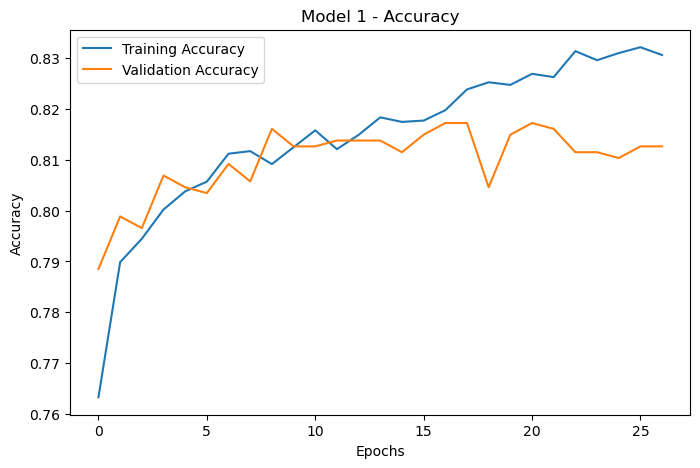

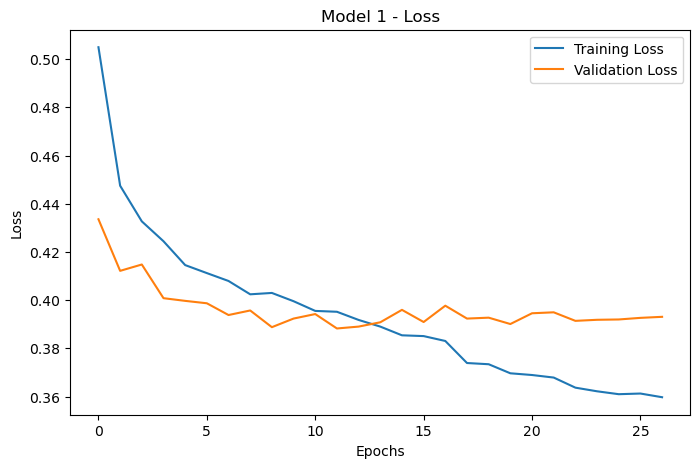

In [245]:
plt.figure(figsize=(8, 5))

plt.plot(history_1.history["accuracy"], label="Training Accuracy")
plt.plot(history_1.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model 1 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


#========================================================================================================================================


plt.figure(figsize=(8, 5))

plt.plot(history_1.history["loss"], label="Training Loss")
plt.plot(history_1.history["val_loss"], label="Validation Loss")

plt.title("Model 1 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Model 2 

In [246]:
model_2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer=AdamW(
        learning_rate=0.001,
        weight_decay=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

c:\Users\work\anaconda3\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 224 (896.00 B)

### CallBacks Model 2 

In [247]:
er_stoping_2 = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

re_lr_2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

Best_model_2 = ModelCheckpoint(
    "best_model_2.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

train model 2 

In [248]:
history_2 = model_2.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=[
        er_stoping_2,
        re_lr_2,
        Best_model_2
    ]
)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7039 - loss: 0.5890 - val_accuracy: 0.8000 - val_loss: 0.4744 - learning_rate: 0.0010
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7506 - loss: 0.5111 - val_accuracy: 0.7989 - val_loss: 0.4343 - learning_rate: 0.0010
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7571 - loss: 0.4978 - val_accuracy: 0.7931 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7702 - loss: 0.4750 - val_accuracy: 0.8069 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7757 - loss: 0.4700 - val_accuracy: 0.8000 - val_loss: 0.4141 - learning_rate: 0.0010
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7781 - loss: 0.4698 - val_accuracy: 0.8046 - val_loss: 0.4071 - learning_rate: 0.0010
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7844 - los

### Visualize Model 2 

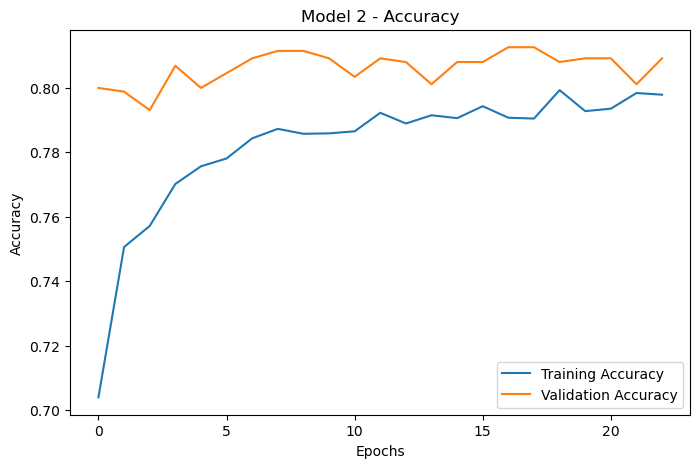

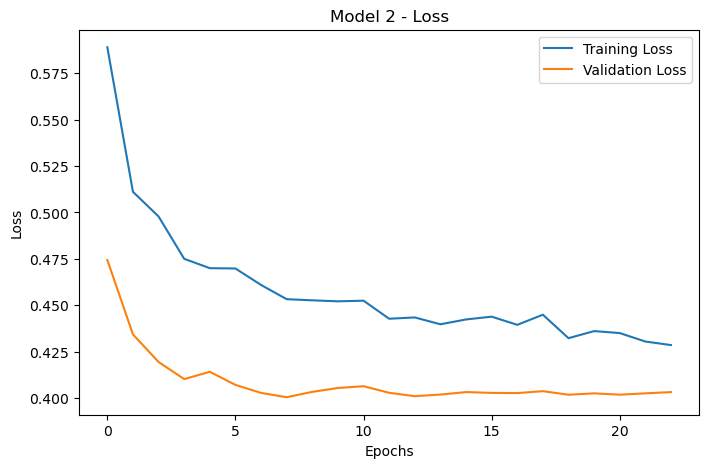

In [249]:
plt.figure(figsize=(8, 5))

plt.plot(history_2.history["accuracy"], label="Training Accuracy")
plt.plot(history_2.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model 2 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

#========================================================================================================================================


plt.figure(figsize=(8, 5))

plt.plot(history_2.history["loss"], label="Training Loss")
plt.plot(history_2.history["val_loss"], label="Validation Loss")

plt.title("Model 2 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


### Combare Between Two Models 

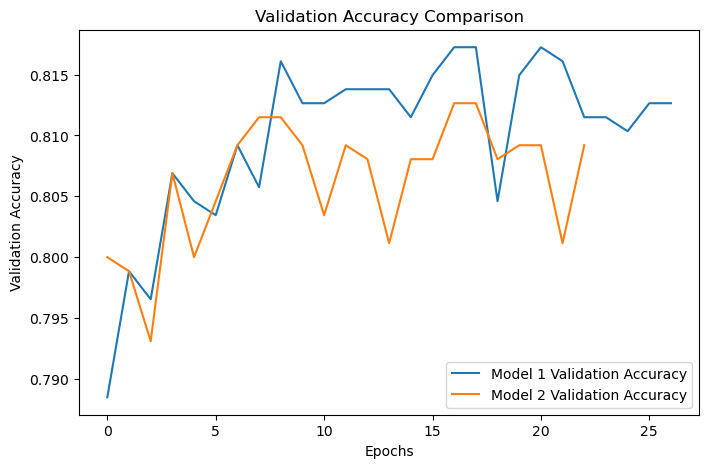

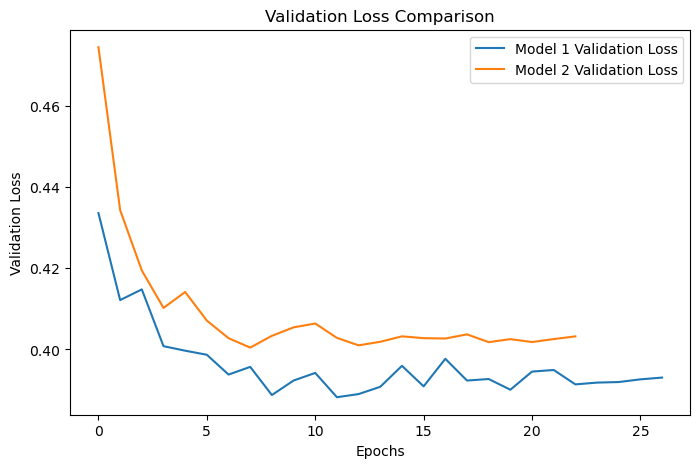

In [250]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_1.history["val_accuracy"],
    label="Model 1 Validation Accuracy"
)

plt.plot(
    history_2.history["val_accuracy"],
    label="Model 2 Validation Accuracy"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

#===================================================================================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_1.history["val_loss"],
    label="Model 1 Validation Loss"
)

plt.plot(
    history_2.history["val_loss"],
    label="Model 2 Validation Loss"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()

### Best Accuracy 

In [ ]:
print("Model 1 Best Val Accuracy:",
    max(history_1.history["val_accuracy"]))

print("Model 2 Best Val Accuracy:",
    max(history_2.history["val_accuracy"]))

Model 1 Best Val Accuracy: 0.817241370677948
Model 2 Best Val Accuracy: 0.8126437067985535
